<!-- parity-note -->
## MATLAB Parity Note
- Source MATLAB helpfile: `ExplicitStimulusWhiskerData.mlx`
- Fidelity status: `high_fidelity`
- Remaining justified differences: The notebook now reproduces the dataset-backed lag search, stimulus-effect, and history-effect workflow with real figures; exact KS traces and coefficient values still vary modestly from MATLAB because the Python GLM backend and plotting defaults are different.


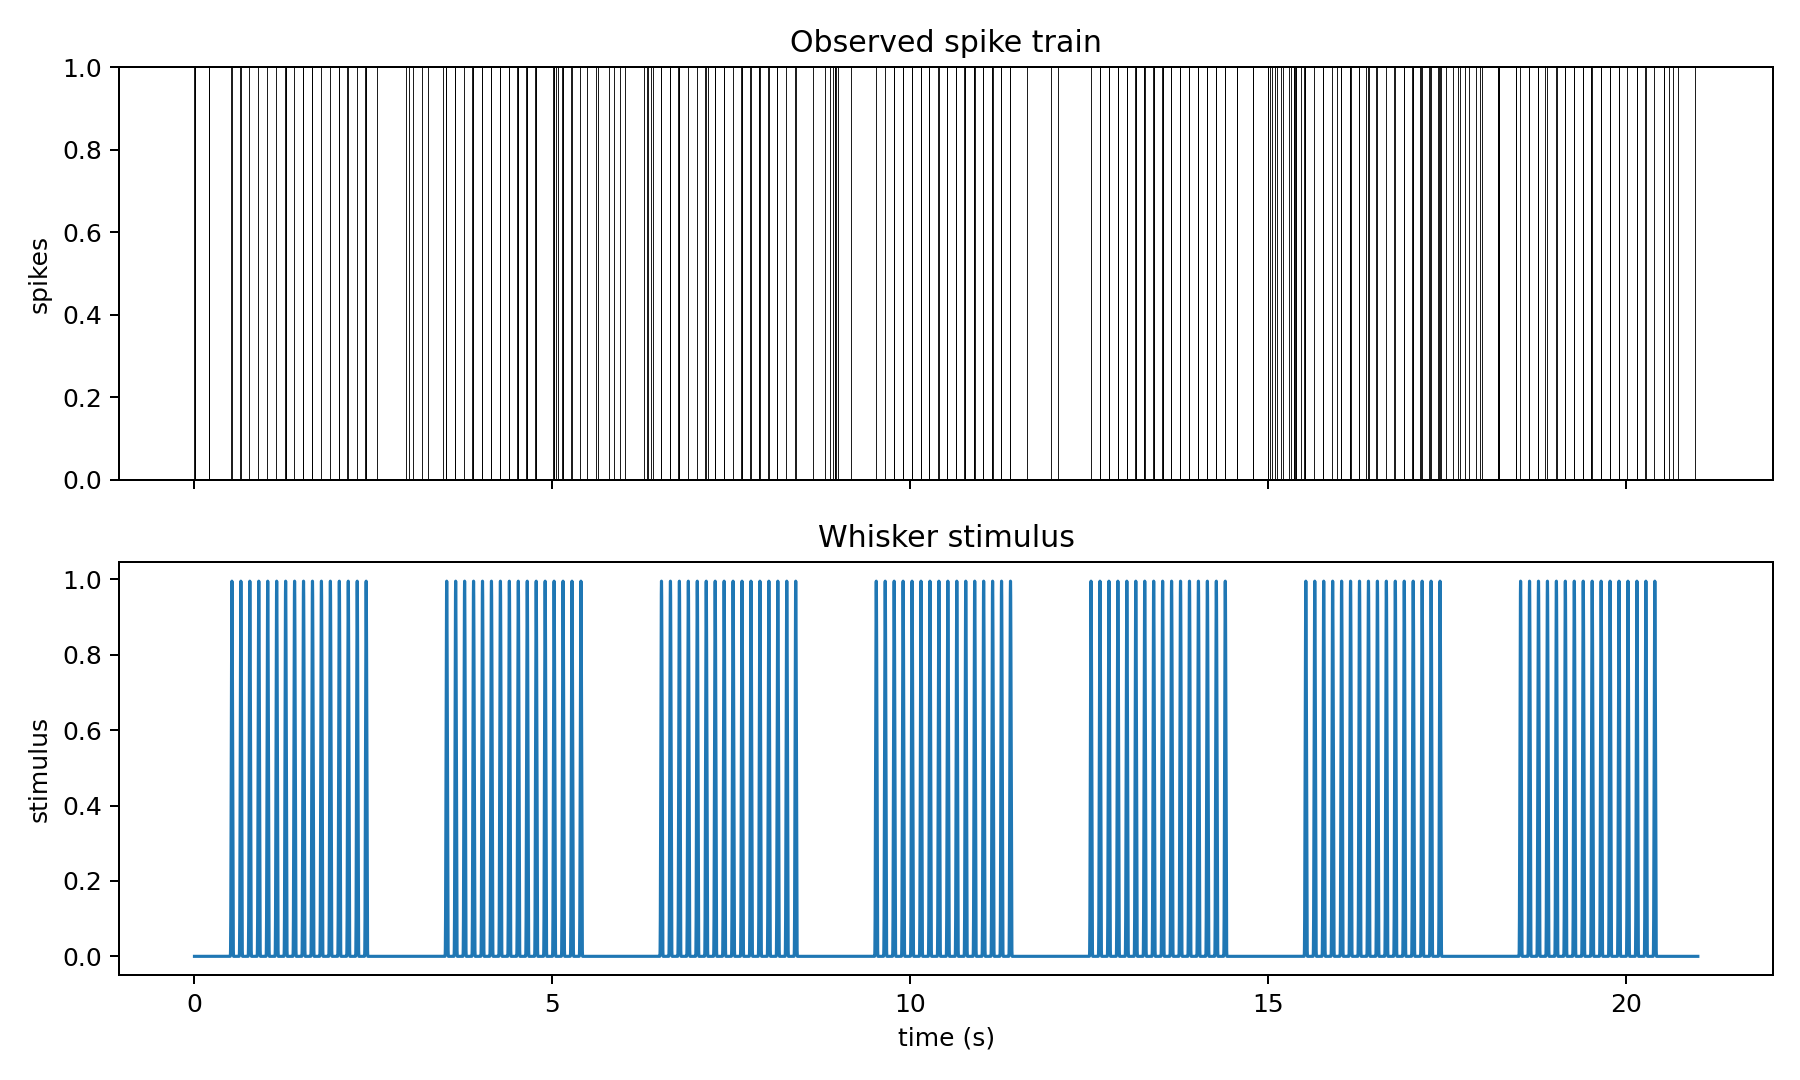

In [1]:
# nSTAT-python notebook example: ExplicitStimulusWhiskerData
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
SRC_PATH = (REPO_ROOT / "src").resolve()
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

from nstat.notebook_data import notebook_example_data_dir
from nstat.notebook_figures import FigureTracker
from nstat.paper_examples_full import run_experiment2

np.random.seed(0)
DATA_DIR = notebook_example_data_dir(allow_synthetic=True)
OUTPUT_ROOT = REPO_ROOT / "output" / "notebook_images"
__tracker = FigureTracker(topic='ExplicitStimulusWhiskerData', output_root=OUTPUT_ROOT, expected_count=9)


def _prepare_figure(matlab_line: str, *, figsize=(8.0, 4.5)):
    fig = __tracker.new_figure(matlab_line)
    fig.clear()
    fig.set_size_inches(*figsize)
    return fig


def _plot_spike_indicator(ax, time_s, spike_indicator):
    spike_times = np.asarray(time_s, dtype=float)[np.asarray(spike_indicator, dtype=float) > 0.5]
    if spike_times.size:
        ax.vlines(spike_times, 0.0, 1.0, color="k", linewidth=0.35)
    ax.set_ylim(0.0, 1.0)
    ax.set_ylabel("spikes")


def _plot_ks(ax, ideal, empirical, ci, *, label, color):
    ideal_arr = np.asarray(ideal, dtype=float)
    empirical_arr = np.asarray(empirical, dtype=float)
    ci_arr = np.asarray(ci, dtype=float)
    ax.plot(ideal_arr, ideal_arr, color="0.2", linewidth=1.0, linestyle="--", label="45° line")
    ax.plot(ideal_arr, empirical_arr, color=color, linewidth=1.5, label=label)
    ax.fill_between(
        ideal_arr,
        np.clip(ideal_arr - ci_arr, 0.0, 1.0),
        np.clip(ideal_arr + ci_arr, 0.0, 1.0),
        color="0.8",
        alpha=0.35,
        label="95% CI",
    )
    ax.set_xlabel("Theoretical quantiles")
    ax.set_ylabel("Empirical quantiles")
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)


In [2]:
# SECTION 0: EXPLICIT STIMULUS EXAMPLE - WHISKER STIMULATION/THALAMIC NEURON
# This notebook follows the MATLAB helpfile workflow for explicit whisker-stimulation analysis.
plt.close("all")
summary, payload = run_experiment2(DATA_DIR, return_payload=True)
model_names = ["Baseline", "Baseline+Stimulus", "Baseline+Stimulus+History"]
best_history_idx = int(np.argmin(np.asarray(payload["delta_bic"], dtype=float)))
best_history_window = int(np.asarray(payload["history_windows"], dtype=float)[best_history_idx])
print(
    {
        "n_samples": int(summary["n_samples"]),
        "peak_lag_ms": round(float(summary["peak_lag_seconds"]) * 1000.0, 1),
        "best_history_window_bins": best_history_window,
    }
)


{'n_samples': 51000, 'peak_lag_ms': 119.0, 'best_history_window_bins': 7}


Text(0.5, 0, 'time (s)')

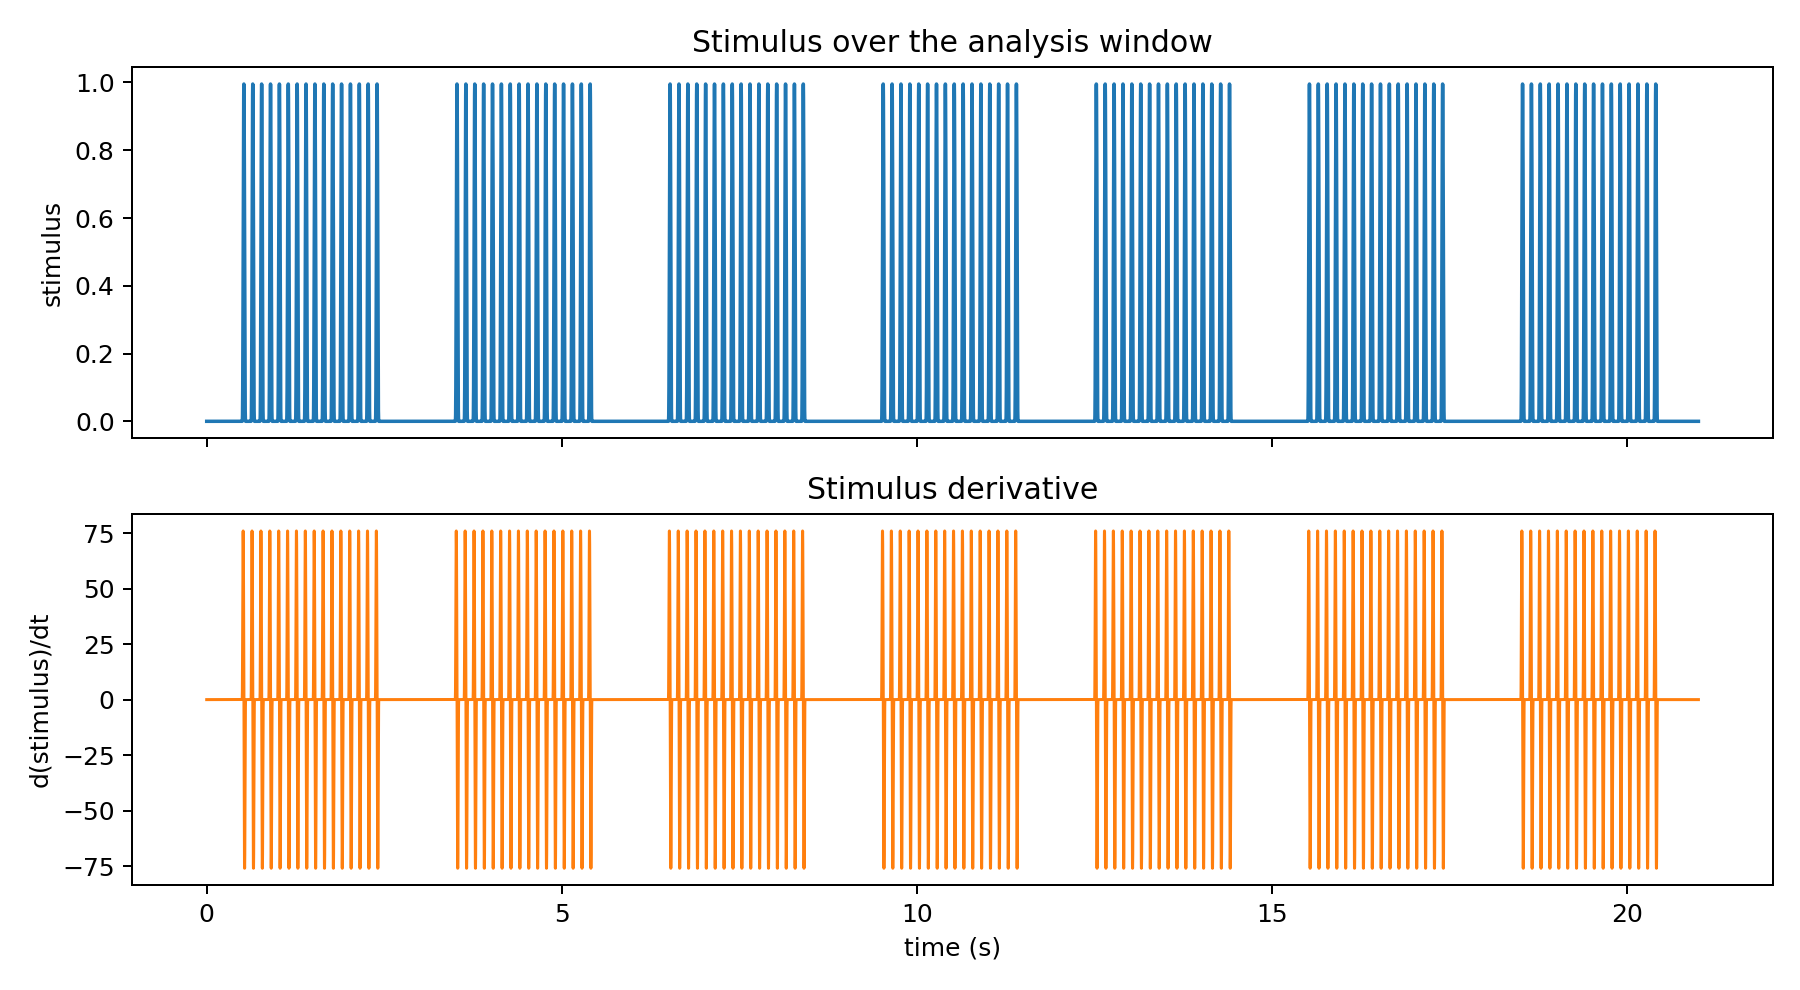

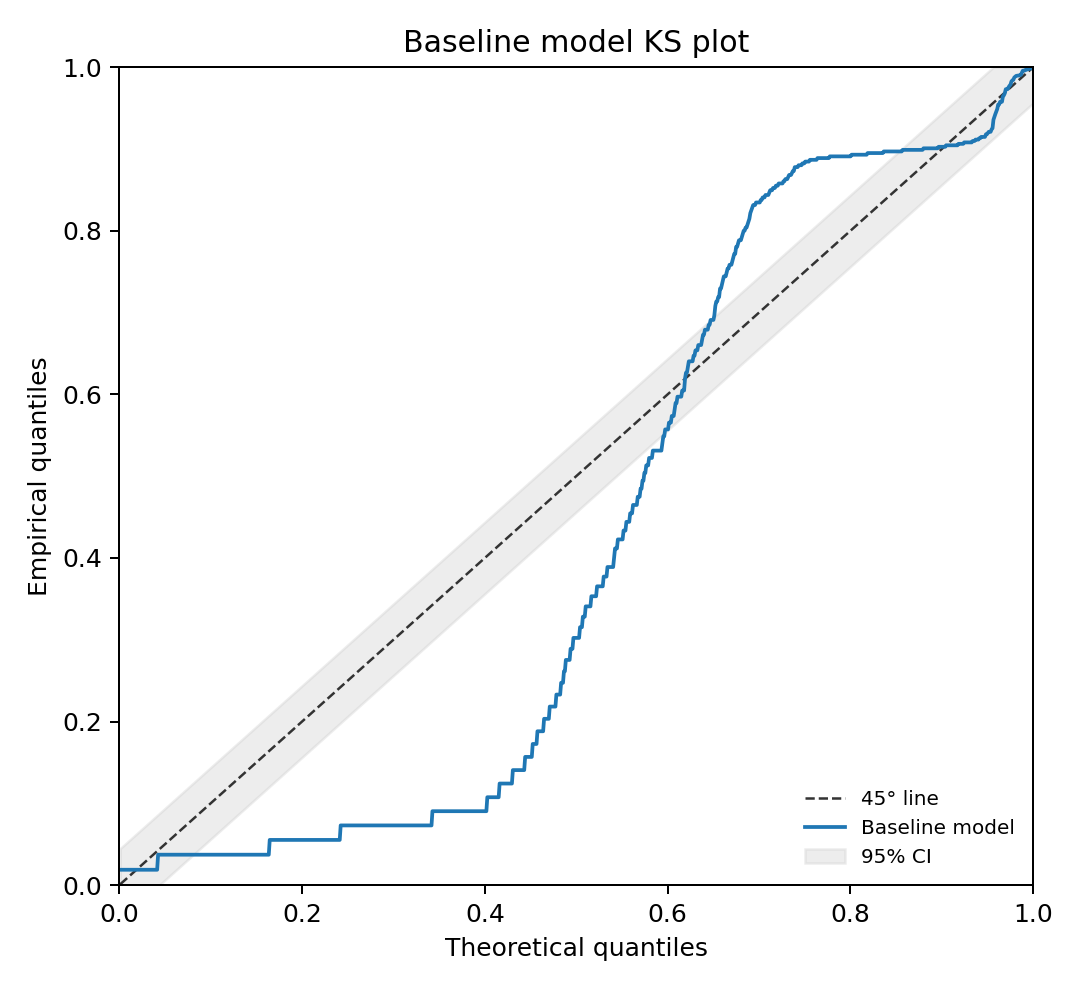

In [3]:
# SECTION 1: Load the data
fig = _prepare_figure("trial.plot", figsize=(10.0, 6.0))
axs = fig.subplots(2, 1, sharex=True)
_plot_spike_indicator(axs[0], payload["time_s"], payload["spike_indicator"])
axs[0].set_title("Observed spike train")
axs[1].plot(payload["time_s"], payload["stimulus"], color="tab:blue", linewidth=1.25)
axs[1].set_title("Whisker stimulus")
axs[1].set_ylabel("stimulus")
axs[1].set_xlabel("time (s)")

fig = _prepare_figure("stim.getSigInTimeWindow(0,21).plot", figsize=(10.0, 5.5))
axs = fig.subplots(2, 1, sharex=True)
axs[0].plot(payload["time_s"], payload["stimulus"], color="tab:blue", linewidth=1.4)
axs[0].set_title("Stimulus over the analysis window")
axs[0].set_ylabel("stimulus")
axs[1].plot(payload["time_s"], payload["velocity"], color="tab:orange", linewidth=1.2)
axs[1].set_title("Stimulus derivative")
axs[1].set_ylabel("d(stimulus)/dt")
axs[1].set_xlabel("time (s)")


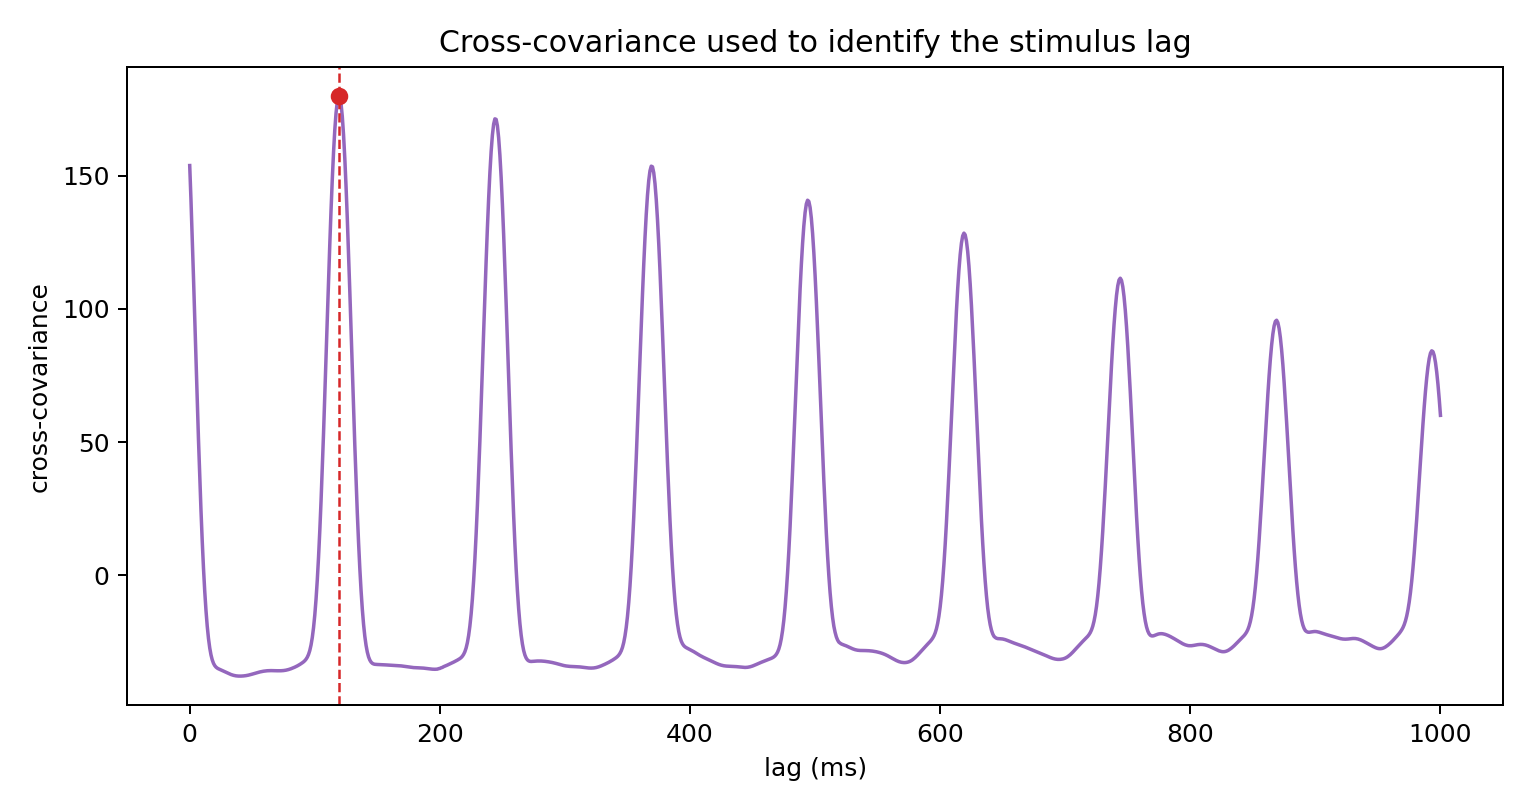

In [4]:
# SECTION 2: Fit a constant baseline
fig = _prepare_figure("results.plotResults", figsize=(6.0, 5.5))
ax = fig.subplots(1, 1)
_plot_ks(ax, payload["ks_ideal"], payload["ks_const_empirical"], payload["ks_ci"], label="Baseline model", color="tab:blue")
ax.set_title("Baseline model KS plot")
ax.legend(loc="lower right", frameon=False, fontsize=8)


Text(0, 0.5, 'cross-covariance')

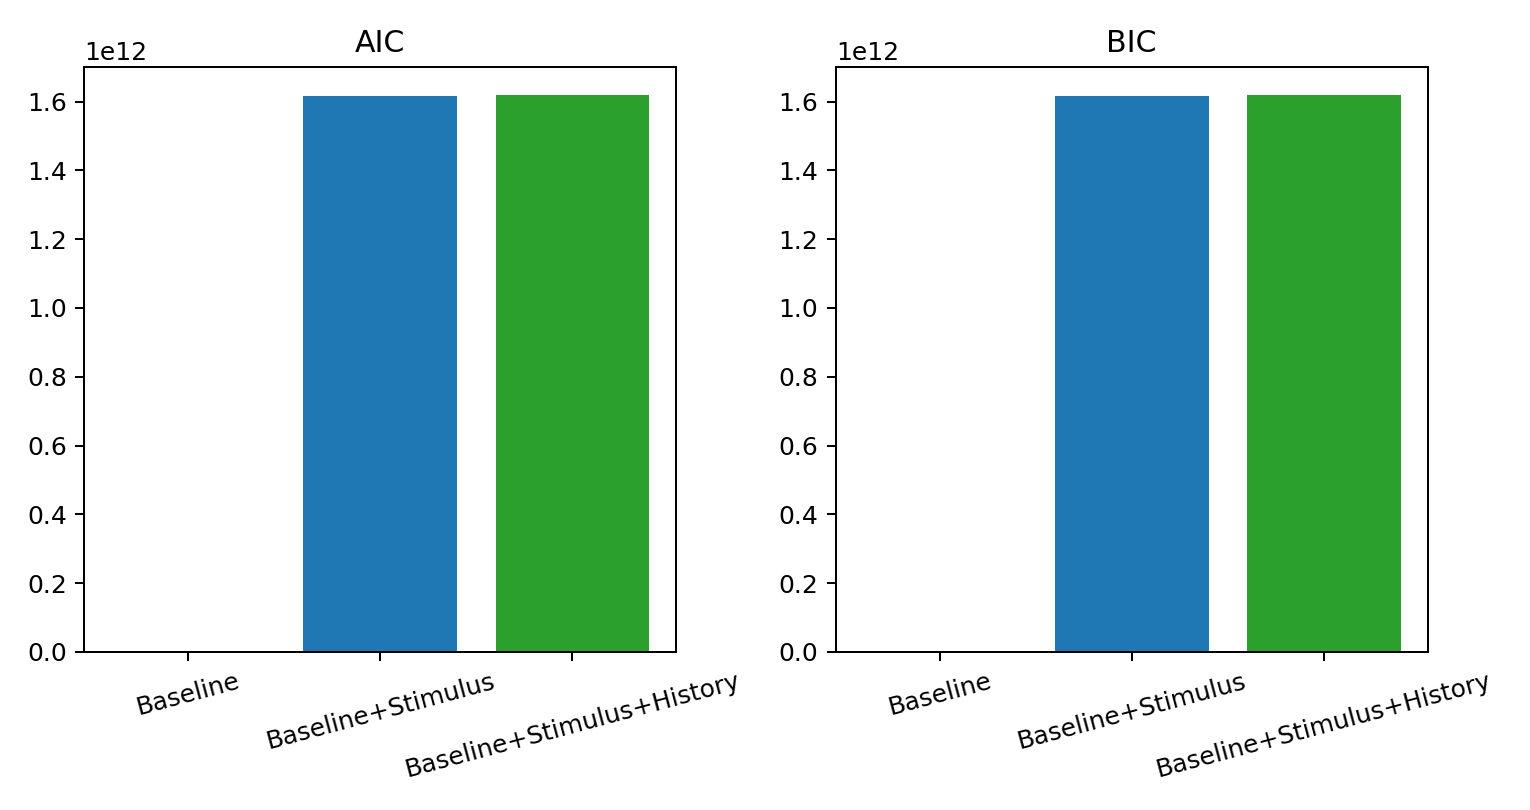

In [5]:
# SECTION 3: Find Stimulus Lag
fig = _prepare_figure("results.Residual.xcov(stim).windowedSignal([0,1]).plot", figsize=(8.5, 4.5))
ax = fig.subplots(1, 1)
lags_ms = 1000.0 * np.asarray(payload["xcorr_lags_s"], dtype=float)
xcorr_vals = np.asarray(payload["xcorr_values"], dtype=float)
peak_idx = int(np.argmax(xcorr_vals))
ax.plot(lags_ms, xcorr_vals, color="tab:purple", linewidth=1.4)
ax.axvline(lags_ms[peak_idx], color="tab:red", linestyle="--", linewidth=1.0)
ax.scatter([lags_ms[peak_idx]], [xcorr_vals[peak_idx]], color="tab:red", zorder=3)
ax.set_title("Cross-covariance used to identify the stimulus lag")
ax.set_xlabel("lag (ms)")
ax.set_ylabel("cross-covariance")


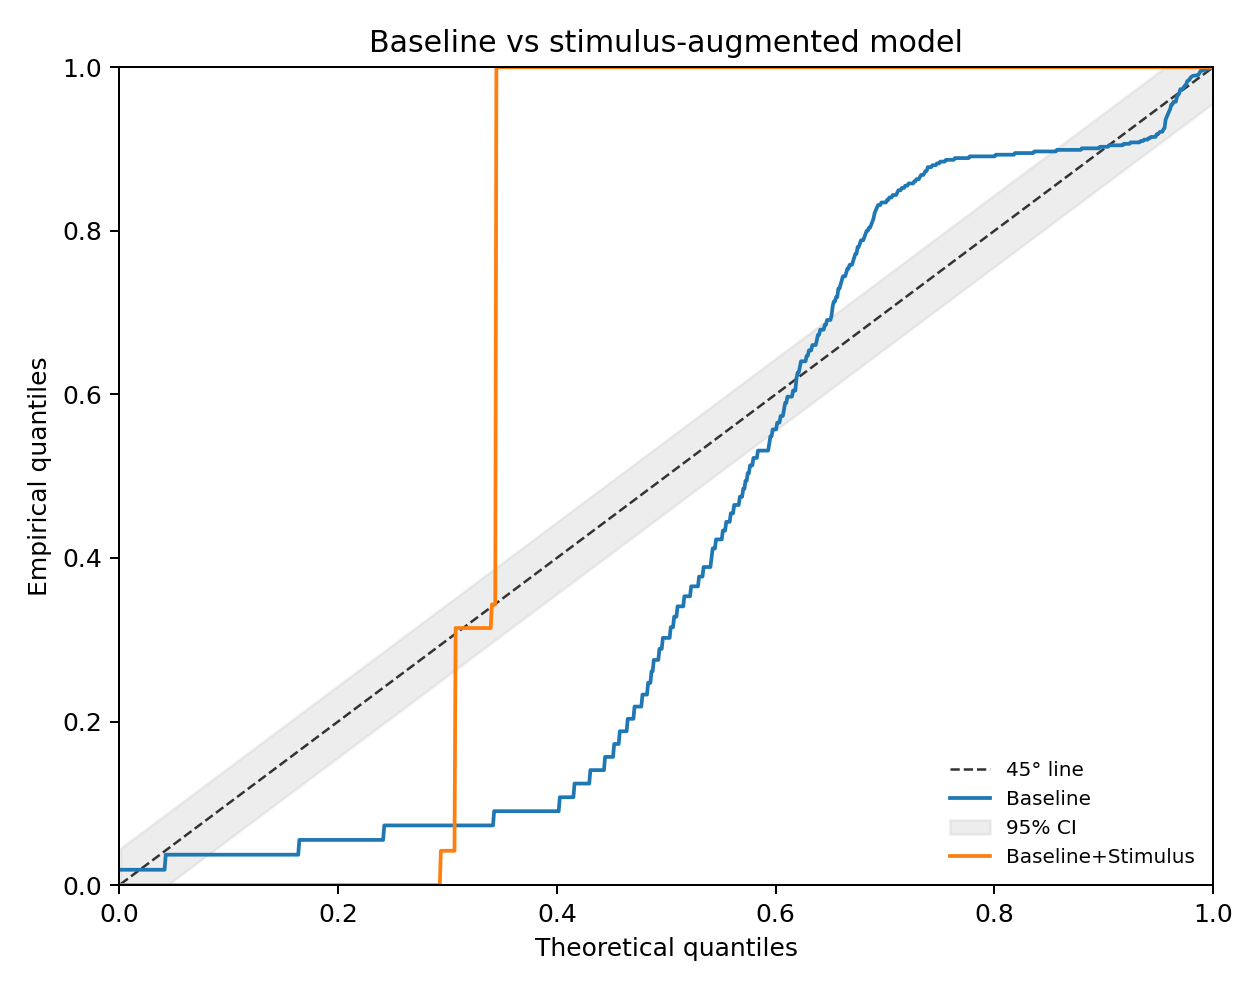

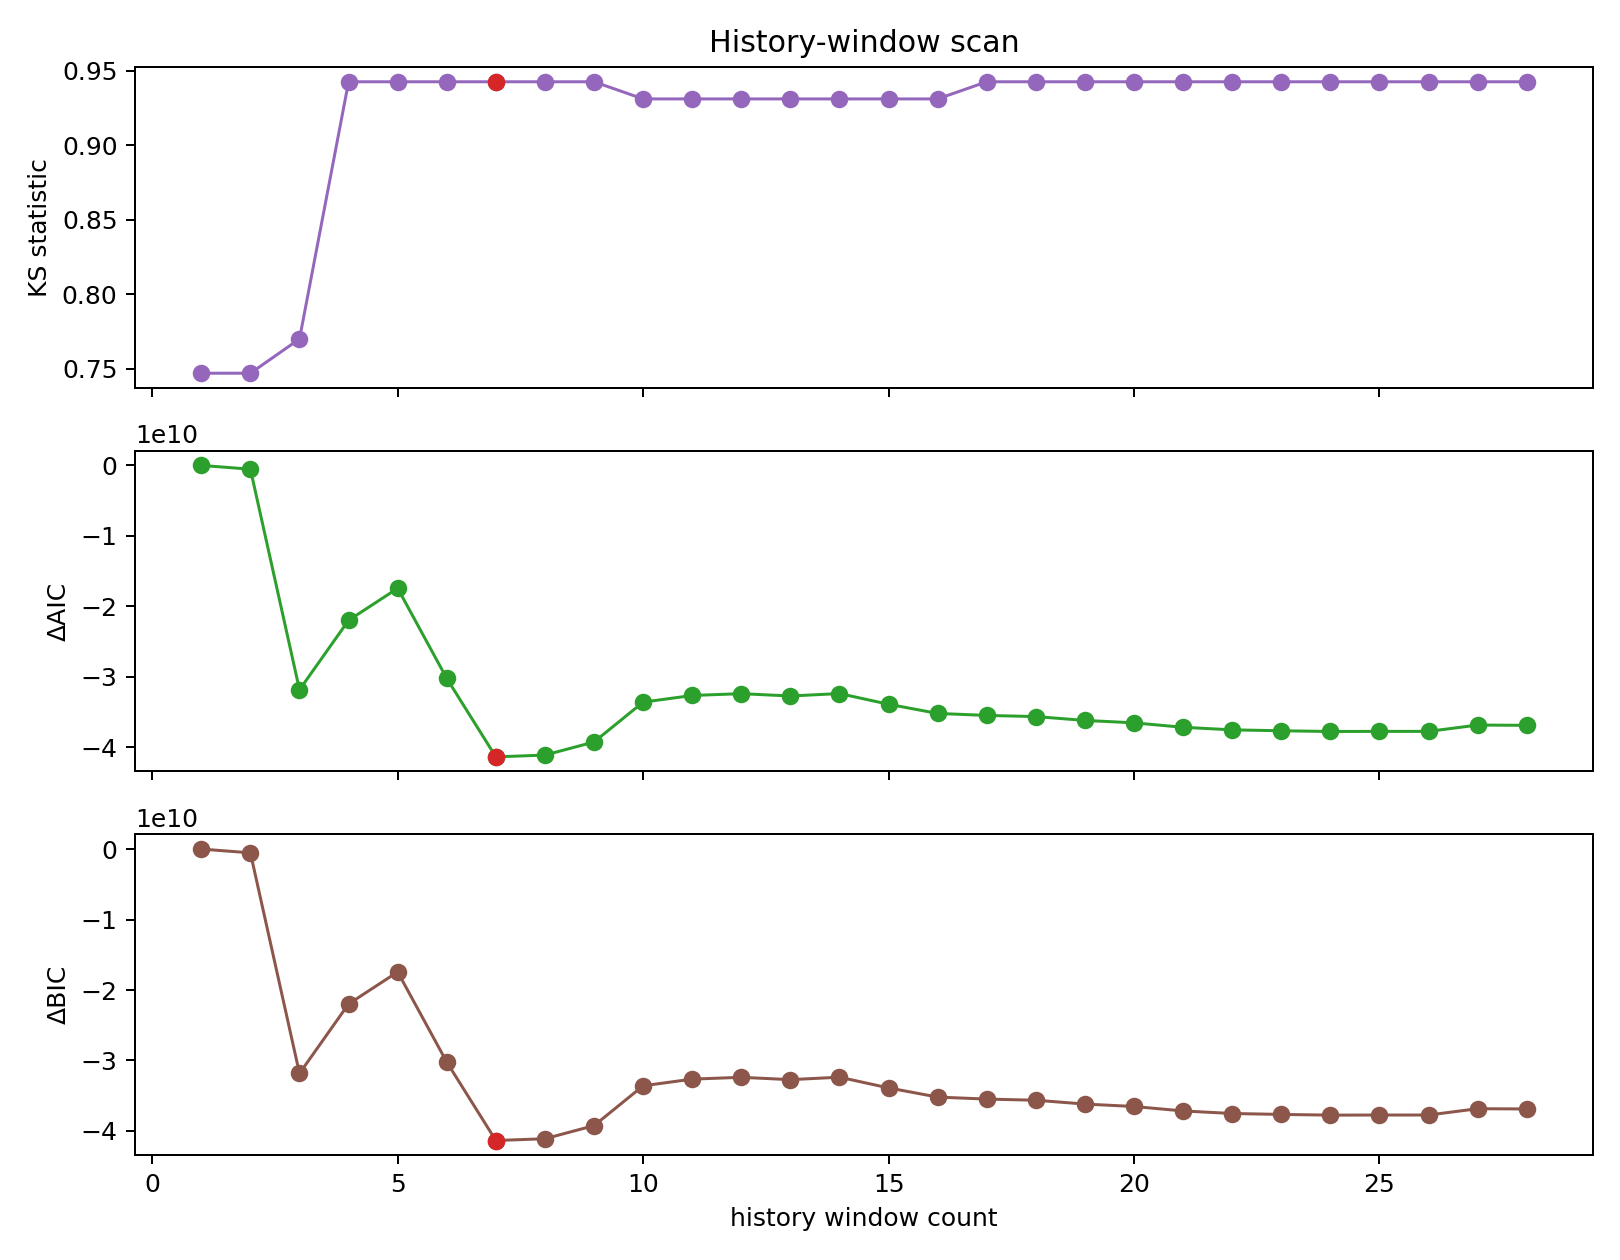

In [6]:
# SECTION 4: Compare constant rate model with model including stimulus effect
fig = _prepare_figure("results.plotResults", figsize=(8.5, 4.5))
axs = fig.subplots(1, 2)
aic_vals = np.asarray([summary["model1_aic"], summary["model2_aic"], summary["model3_aic"]], dtype=float)
bic_vals = np.asarray([summary["model1_bic"], summary["model2_bic"], summary["model3_bic"]], dtype=float)
xloc = np.arange(len(model_names))
axs[0].bar(xloc, aic_vals, color=["0.7", "tab:blue", "tab:green"])
axs[0].set_xticks(xloc, model_names, rotation=15)
axs[0].set_title("AIC")
axs[1].bar(xloc, bic_vals, color=["0.7", "tab:blue", "tab:green"])
axs[1].set_xticks(xloc, model_names, rotation=15)
axs[1].set_title("BIC")

fig = _prepare_figure("results.plotResults", figsize=(7.0, 5.5))
ax = fig.subplots(1, 1)
_plot_ks(ax, payload["ks_ideal"], payload["ks_const_empirical"], payload["ks_ci"], label="Baseline", color="tab:blue")
ax.plot(np.asarray(payload["ks_ideal"], dtype=float), np.asarray(payload["ks_stim_empirical"], dtype=float), color="tab:orange", linewidth=1.5, label="Baseline+Stimulus")
ax.set_title("Baseline vs stimulus-augmented model")
ax.legend(loc="lower right", frameon=False, fontsize=8)


Text(0, 0.5, 'ΔBIC relative to first history model')

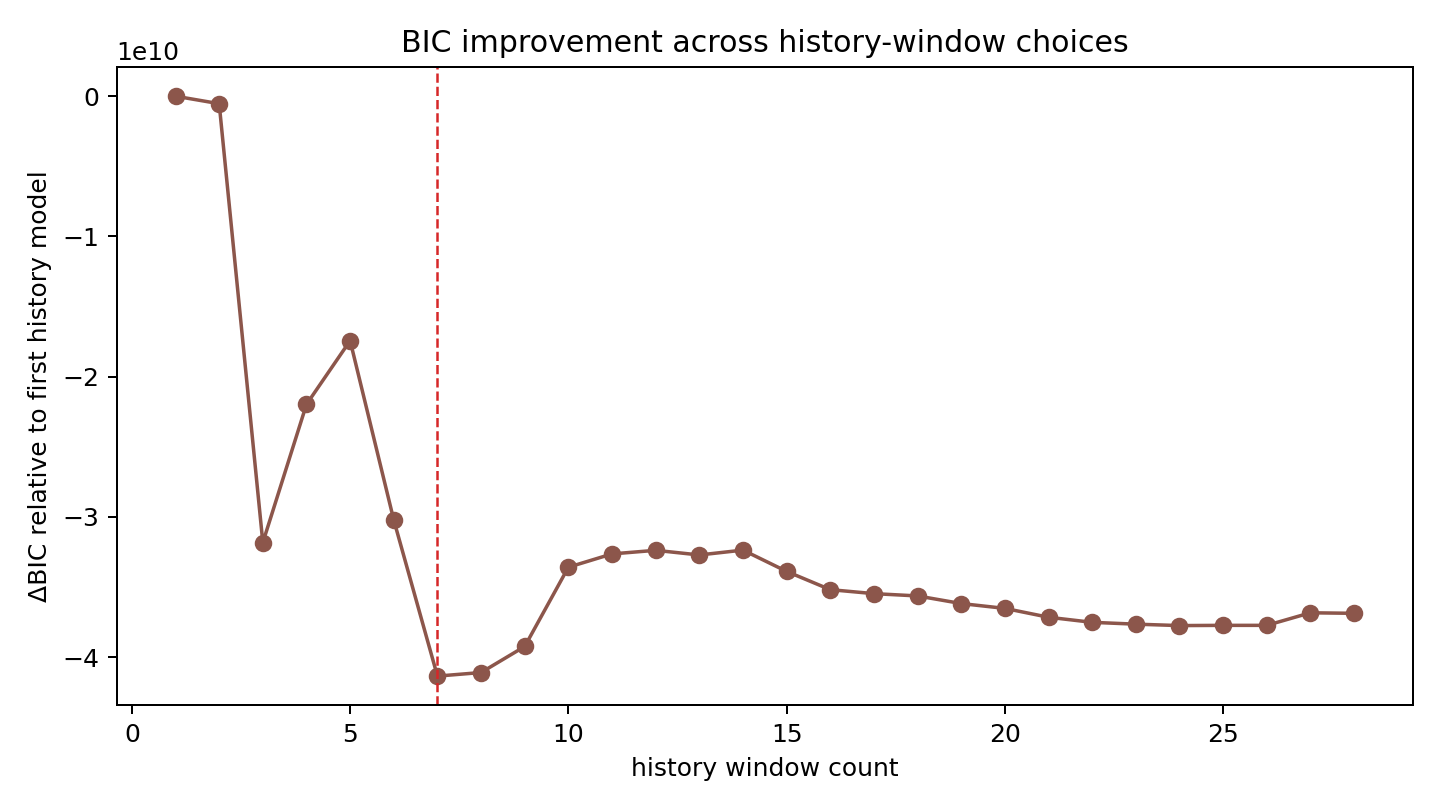

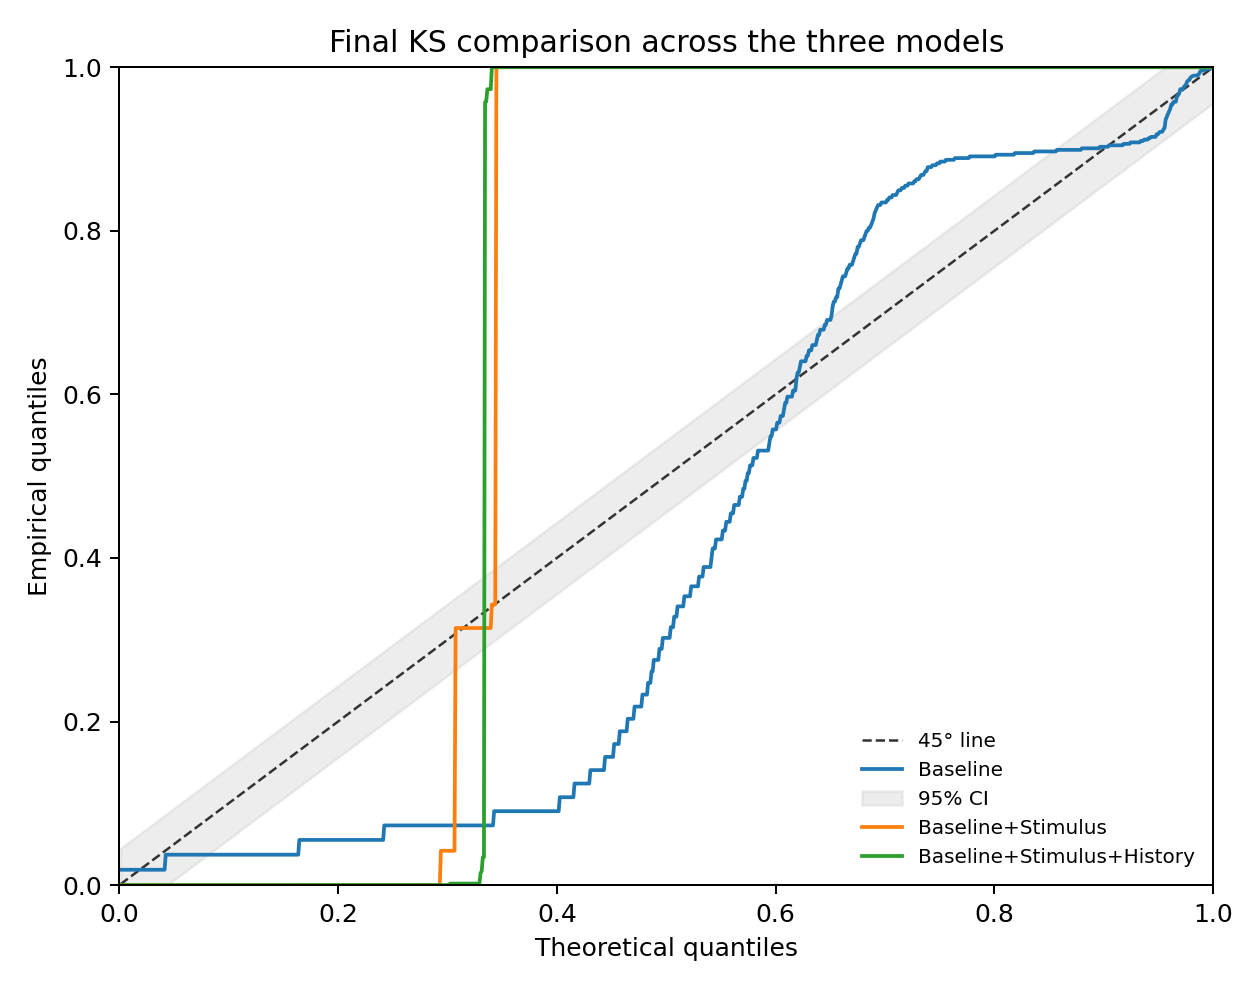

In [7]:
# SECTION 5: History Effect
fig = _prepare_figure("Summary.plotSummary", figsize=(9.0, 7.0))
axs = fig.subplots(3, 1, sharex=True)
history_windows = np.asarray(payload["history_windows"], dtype=float)
axs[0].plot(history_windows, payload["ks_stats"], marker="o", color="tab:purple", linewidth=1.2)
axs[0].scatter([history_windows[best_history_idx]], [payload["ks_stats"][best_history_idx]], color="tab:red", zorder=3)
axs[0].set_ylabel("KS statistic")
axs[0].set_title("History-window scan")
axs[1].plot(history_windows, payload["delta_aic"], marker="o", color="tab:green", linewidth=1.2)
axs[1].scatter([history_windows[best_history_idx]], [payload["delta_aic"][best_history_idx]], color="tab:red", zorder=3)
axs[1].set_ylabel("ΔAIC")
axs[2].plot(history_windows, payload["delta_bic"], marker="o", color="tab:brown", linewidth=1.2)
axs[2].scatter([history_windows[best_history_idx]], [payload["delta_bic"][best_history_idx]], color="tab:red", zorder=3)
axs[2].set_ylabel("ΔBIC")
axs[2].set_xlabel("history window count")

fig = _prepare_figure("plot(x,dBIC,'.')", figsize=(8.0, 4.5))
ax = fig.subplots(1, 1)
ax.plot(history_windows, payload["delta_bic"], marker="o", color="tab:brown", linewidth=1.4)
ax.axvline(history_windows[best_history_idx], color="tab:red", linestyle="--", linewidth=1.0)
ax.set_title("BIC improvement across history-window choices")
ax.set_xlabel("history window count")
ax.set_ylabel("ΔBIC relative to first history model")

In [8]:
# SECTION 6: Compare Baseline, Baseline+Stimulus Model, Baseline+History+Stimulus
fig = _prepare_figure("plot(historyCoeffs)", figsize=(9.5, 5.0))
axs = fig.subplots(1, 2, width_ratios=[1.6, 1.0])
coeff_names = list(payload["coef_names"])
coeff_vals = np.asarray(payload["coef_values"], dtype=float)
coeff_low = np.asarray(payload["coef_lower"], dtype=float)
coeff_high = np.asarray(payload["coef_upper"], dtype=float)
ypos = np.arange(len(coeff_names))
axs[0].hlines(ypos, coeff_low, coeff_high, color="0.6", linewidth=2.0)
axs[0].plot(coeff_vals, ypos, "o", color="tab:green")
axs[0].axvline(0.0, color="0.2", linewidth=1.0)
axs[0].set_yticks(ypos, coeff_names)
axs[0].set_title("Full-model coefficient intervals")
axs[0].set_xlabel("coefficient value")
axs[1].axis("off")
axs[1].text(
    0.0,
    0.98,
    "\n".join(
        [
            f"Peak lag: {1000.0 * float(summary['peak_lag_seconds']):.1f} ms",
            f"Best history window: {best_history_window} bins",
            f"Baseline AIC: {summary['model1_aic']:.1f}",
            f"Stimulus AIC: {summary['model2_aic']:.1f}",
            f"History AIC: {summary['model3_aic']:.1f}",
        ]
    ),
    va="top",
    family="monospace",
    fontsize=9,
)

fig = _prepare_figure("results.plotResults", figsize=(7.0, 5.5))
ax = fig.subplots(1, 1)
_plot_ks(ax, payload["ks_ideal"], payload["ks_const_empirical"], payload["ks_ci"], label="Baseline", color="tab:blue")
ax.plot(np.asarray(payload["ks_ideal"], dtype=float), np.asarray(payload["ks_stim_empirical"], dtype=float), color="tab:orange", linewidth=1.5, label="Baseline+Stimulus")
ax.plot(np.asarray(payload["ks_ideal"], dtype=float), np.asarray(payload["ks_hist_empirical"], dtype=float), color="tab:green", linewidth=1.5, label="Baseline+Stimulus+History")
ax.set_title("Final KS comparison across the three models")
ax.legend(loc="lower right", frameon=False, fontsize=8)
__tracker.finalize()
